# FMD tblastn Breakdown: Strict Clean

Focused validation notebook for FMD only.

Flow:

1. Run tblastn on strict-clean FMD records.
2. Compare predictions with annotated FMD truth.
3. Report raw exact/coordinate accuracy.
4. Use the FMD reference model to explain non-exact cases as ref/truth mismatch or tool-side boundary issues.

Outputs are written to `outputs_fmd/`.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from app.validation._shared.validation_utils import *

TIER = 'strict_clean'
BASE_DIR = Path.cwd()
if not (BASE_DIR / 'inputs').exists() and (BASE_DIR / 'tiers' / TIER / 'inputs').exists():
    BASE_DIR = BASE_DIR / 'tiers' / TIER

INPUT_DIR = BASE_DIR / 'inputs'
OUTPUT_DIR = BASE_DIR / 'outputs_fmd'
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})

RAW_COLORS = {
    'exact_match': '#2f7d4f',
    'coord_only': '#75b66b',
    'failed_coord_or_name': '#c44e52',
}

BLAME_COLORS = {
    'ref_truth': '#4c78a8',
    'tool': '#c44e52',
}


## Inputs

Only FMD strict-clean records are used here.

In [2]:
manifest = pd.read_csv(INPUT_DIR / 'manifest.tsv', sep='	')
fmd_manifest = manifest[(manifest['virus'] == 'FMD') & (manifest['keep'] == True)].copy()
input_summary = pd.read_csv(INPUT_DIR / 'summary.tsv', sep='	')
input_summary[input_summary['virus'] == 'FMD']

,virus,reason,records,kept
0,FMD,kept_clean,96,96
1,FMD,duplicate_canonical_names,2,0
2,FMD,no_truth_features,2,0


## Run FMD tblastn And Compare To Truth

This cell reruns FMD tblastn with the current code. It may take a while.

In [3]:
fmd_df, fmd_summary = run_tblastn_against_truth(
    virus_label='FMD',
    ref_path=DATA / 'FMD_ref_test.gb',
    query_path=INPUT_DIR / 'FMD_records.gb',
    output_dir=OUTPUT_DIR / 'fmd',
    progress=True,
)

fmd_df.to_csv(OUTPUT_DIR / 'fmd_tblastn_vs_truth.tsv', sep='	', index=False)
fmd_summary.to_csv(OUTPUT_DIR / 'fmd_tblastn_summary.tsv', sep='	', index=False)
fmd_summary

tblastn  FMD:   0%|          | 0/96 [00:00<?, ?rec/s]

,virus,method,total,exact,coord_correct,mean_iou,exact_pct,coord_pct
0,FMD,tblastn,1152,1114,1130,0.9944,96.7,98.09


## Raw Accuracy

- `exact_match`: name/start/end all match truth.
- `coord_only`: name matches and IoU >= 0.90, but boundary differs.
- `failed_coord_or_name`: name missing/mismatched or coordinates below threshold.

In [4]:
total = len(fmd_df)
exact = int(fmd_df['exact_match'].sum())
coord = int(fmd_df['coord_correct'].sum())
raw_accuracy = pd.DataFrame([{
    'virus': 'FMD',
    'total': total,
    'exact_match': exact,
    'coord_correct': coord,
    'coord_only': coord - exact,
    'failed_coord_or_name': total - coord,
    'exact_pct': round(exact / total * 100, 2),
    'coord_pct': round(coord / total * 100, 2),
    'failed_pct': round((total - coord) / total * 100, 2),
}])
raw_accuracy.to_csv(OUTPUT_DIR / 'fmd_raw_accuracy.tsv', sep='	', index=False)
raw_accuracy

,virus,total,exact_match,coord_correct,coord_only,failed_coord_or_name,exact_pct,coord_pct,failed_pct
0,FMD,1152,1114,1130,16,22,96.7,98.09,1.91


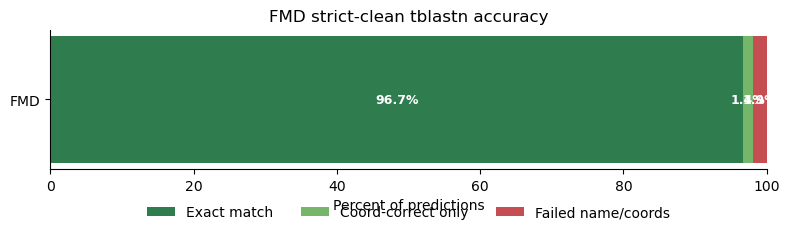

In [5]:
plot_df = raw_accuracy.set_index('virus')[['exact_match', 'coord_only', 'failed_coord_or_name']]
plot_pct = plot_df.div(plot_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 2.8))
left = pd.Series(0.0, index=plot_pct.index)
labels = {
    'exact_match': 'Exact match',
    'coord_only': 'Coord-correct only',
    'failed_coord_or_name': 'Failed name/coords',
}
for col in ['exact_match', 'coord_only', 'failed_coord_or_name']:
    vals = plot_pct[col]
    bars = ax.barh(plot_pct.index, vals, left=left, color=RAW_COLORS[col], label=labels[col])
    for bar, value, start in zip(bars, vals, left):
        if value >= 1:
            ax.text(start + value / 2, bar.get_y() + bar.get_height() / 2, f'{value:.1f}%',
                    ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    left += vals

ax.set_xlim(0, 100)
ax.set_xlabel('Percent of predictions')
ax.set_title('FMD strict-clean tblastn accuracy')
ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.45), frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fmd_raw_accuracy.png', dpi=180, bbox_inches='tight')


## FMD Reference Model

This is the annotation model transferred by tblastn. If prediction length matches ref but query truth differs, the failure is usually a ref/query truth convention mismatch.

In [6]:
fmd_bundle = load_reference_bundle(DATA / 'FMD_ref_test.gb')
fmd_ref_model = pd.DataFrame([
    {
        'ref_name': feature['name'],
        'ref_start': feature['start'],
        'ref_end': feature['end'],
        'ref_len': feature['end'] - feature['start'] + 1,
        'ref_strand': feature.get('strand', '+'),
    }
    for feature in fmd_bundle['features']
])
fmd_ref_model.to_csv(OUTPUT_DIR / 'fmd_reference_model.tsv', sep='	', index=False)
fmd_ref_model

,ref_name,ref_start,ref_end,ref_len,ref_strand
0,Lpro,1184,1786,603,+
1,VP4,1787,2041,255,+
2,VP2,2042,2695,654,+
3,VP3,2696,3355,660,+
4,VP1,3356,3988,633,+
5,2A,3989,4042,54,+
6,2B,4043,4504,462,+
7,2C,4505,5458,954,+
8,3A,5459,5917,459,+
9,3B,5918,6130,213,+


## Ref-Aware Failure Evidence

Every non-exact case is compared against both ref and truth lengths.

In [7]:
def _format_delta(series):
    values = pd.to_numeric(series, errors='coerce').dropna()
    if values.empty:
        return ''
    unique = sorted(values.unique())
    if len(unique) <= 5:
        return ', '.join(str(int(v)) if float(v).is_integer() else f'{v:g}' for v in unique)
    return f'median {values.median():.0f}; range {values.min():.0f}..{values.max():.0f}'


def _top_value(series):
    counts = series.dropna().astype(str).value_counts()
    return counts.index[0] if not counts.empty else ''


fmd_failures = fmd_df[~fmd_df['exact_match']].copy()
if not fmd_failures.empty:
    if 'ref_name' not in fmd_failures.columns:
        fmd_failures['ref_name'] = fmd_failures['pred_name']
    fmd_failures['delta_start'] = fmd_failures['pred_start'] - fmd_failures['truth_start']
    fmd_failures['delta_end'] = fmd_failures['pred_end'] - fmd_failures['truth_end']
    fmd_failures['pred_len'] = fmd_failures['pred_end'] - fmd_failures['pred_start'] + 1
    fmd_failures['truth_len'] = fmd_failures['truth_end'] - fmd_failures['truth_start'] + 1
    fmd_failures = fmd_failures.merge(fmd_ref_model, on='ref_name', how='left')
    fmd_failures['pred_minus_ref_len'] = fmd_failures['pred_len'] - fmd_failures['ref_len']
    fmd_failures['truth_minus_ref_len'] = fmd_failures['truth_len'] - fmd_failures['ref_len']
    fmd_failures['pred_minus_truth_len'] = fmd_failures['pred_len'] - fmd_failures['truth_len']

fmd_failures.to_csv(OUTPUT_DIR / 'fmd_failure_cases_with_ref.tsv', sep='	', index=False)

case_cols = [
    'record_id', 'ref_name', 'truth_name', 'best_overlap_name',
    'ref_len', 'pred_len', 'truth_len', 'pred_minus_ref_len', 'truth_minus_ref_len', 'pred_minus_truth_len',
    'pred_start', 'pred_end', 'truth_start', 'truth_end', 'delta_start', 'delta_end',
    'failure_mode', 'status', 'coverage', 'identity', 'iou', 'best_iou',
]
case_cols = [col for col in case_cols if col in fmd_failures.columns]
fmd_failures[case_cols].head(40)

,record_id,ref_name,truth_name,best_overlap_name,ref_len,pred_len,truth_len,pred_minus_ref_len,truth_minus_ref_len,pred_minus_truth_len,...,truth_start,truth_end,delta_start,delta_end,failure_mode,status,coverage,identity,iou,best_iou
0,AY687333.1,VP1,VP1,VP1,633,630.0,636.0,-3.0,3.0,-6.0,...,3251.0,3886.0,0.0,-6.0,Boundary offset,ok,1.0000,71.1,0.9906,0.9906
1,AY687333.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,3887.0,3934.0,-6.0,0.0,Wrong coords,ok,1.0000,88.9,0.8889,0.8889
2,AY687334.1,VP4,None,VP2,255,255.0,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,Possible overlap,ok,1.0000,96.5,0.0000,0.2673
3,AY687334.1,VP2,VP2,VP2,654,654.0,954.0,0.0,300.0,-300.0,...,1639.0,2592.0,300.0,0.0,Wrong coords,ok,1.0000,84.9,0.6855,0.6855
4,AY687334.1,VP1,VP1,VP1,633,627.0,633.0,-6.0,0.0,-6.0,...,3250.0,3882.0,0.0,-6.0,Boundary offset,ok,1.0000,71.1,0.9905,0.9905
5,AY687334.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,3883.0,3930.0,-6.0,0.0,Wrong coords,ok,1.0000,88.9,0.8889,0.8889
6,DQ989316.1,VP3,None,None,660,234.0,NaN,-426.0,NaN,NaN,...,NaN,NaN,NaN,NaN,Not in truth,low_coverage,0.3591,74.7,0.0000,0.0000
7,DQ989316.1,VP1,None,None,633,468.0,NaN,-165.0,NaN,NaN,...,NaN,NaN,NaN,NaN,Not in truth,ok,0.7488,70.3,0.0000,0.0000
8,FJ175666.1,2A,2A,None,54,NaN,54.0,NaN,0.0,NaN,...,3986.0,4039.0,NaN,NaN,Not lifted,no_hit,0.0000,NaN,0.0000,0.0000
9,LC036265.1,VP1,VP1,VP1,633,633.0,639.0,0.0,6.0,-6.0,...,3270.0,3908.0,0.0,-6.0,Boundary offset,ok,1.0000,91.5,0.9906,0.9906


## Final Adjudication

This section assigns each non-exact case to a concrete cause. `tool` includes strict boundary errors as well as severe misses; the cause column preserves severity.

In [8]:
def _fmd_final_reason(row):
    feature = row['ref_name']
    mode = row.get('failure_mode')
    ds = row.get('delta_start')
    de = row.get('delta_end')
    pred_ref = row.get('pred_minus_ref_len')
    truth_ref = row.get('truth_minus_ref_len')

    if pd.isna(row.get('truth_name')):
        return pd.Series({
            'final_blame': 'ref_truth',
            'final_cause': 'truth_feature_absent',
            'final_explanation': 'Query truth lacks the same-name feature, so the prediction cannot be scored against this truth set.',
        })
    if pred_ref == 0 and truth_ref != 0:
        return pd.Series({
            'final_blame': 'ref_truth',
            'final_cause': 'ref_query_boundary_convention_mismatch',
            'final_explanation': 'Prediction length matches the reference feature, but query truth uses a different feature boundary.',
        })
    if mode == 'Not lifted':
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'no_hit',
            'final_explanation': 'The feature exists in truth but tblastn did not produce a usable hit.',
        })
    if feature == '3A' and ds == 0 and de == -111:
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'major_c_terminal_truncation',
            'final_explanation': 'Start matches truth, but prediction ends 111 bp early and matches neither ref nor truth length.',
        })
    if feature in {'Lpro', '3Cpro'} and ds == 12 and de == 0:
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'n_terminal_truncation_12bp',
            'final_explanation': 'Ref and truth lengths agree, but prediction starts 12 bp downstream, truncating the N-terminus by 4 aa.',
        })
    if feature == '2A' and mode == 'Boundary offset':
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'short_peptide_boundary_offset',
            'final_explanation': 'Prediction differs from ref/truth by 3 bp in a very short peptide; small boundary error is amplified by IoU.',
        })
    if feature == '3B' and de == -3:
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'minor_c_terminal_truncation_3bp',
            'final_explanation': 'Prediction ends 3 bp before ref/truth, a one-codon C-terminal truncation.',
        })
    if feature == 'VP1':
        return pd.Series({
            'final_blame': 'tool',
            'final_cause': 'minor_vp1_boundary_offset',
            'final_explanation': 'Prediction does not match both ref and truth boundary; offset is small and IoU remains high, but it is tool-side under strict scoring.',
        })
    return pd.Series({
        'final_blame': 'tool',
        'final_cause': 'boundary_offset_matches_neither_ref_nor_truth',
        'final_explanation': 'Prediction boundary matches neither ref nor query truth under strict comparison.',
    })

if fmd_failures.empty:
    fmd_final = pd.DataFrame()
else:
    final_cols = fmd_failures.apply(_fmd_final_reason, axis=1)
    fmd_final = pd.concat([fmd_failures, final_cols], axis=1)

fmd_final.to_csv(OUTPUT_DIR / 'fmd_failure_final_adjudication.tsv', sep='	', index=False)

fmd_final_blame_summary = (
    fmd_final.groupby('final_blame')
    .size()
    .reset_index(name='cases')
    if not fmd_final.empty else pd.DataFrame(columns=['final_blame', 'cases'])
)
if not fmd_final_blame_summary.empty:
    fmd_final_blame_summary['pct_of_failures'] = (fmd_final_blame_summary['cases'] / len(fmd_final) * 100).round(2)
    fmd_final_blame_summary['pct_of_all_predictions'] = (fmd_final_blame_summary['cases'] / total * 100).round(2)

fmd_final_blame_summary.to_csv(OUTPUT_DIR / 'fmd_failure_final_blame_summary.tsv', sep='	', index=False)
fmd_final_blame_summary

,final_blame,cases,pct_of_failures,pct_of_all_predictions
0,ref_truth,29,76.32,2.52
1,tool,9,23.68,0.78


In [9]:
fmd_final_summary = (
    fmd_final.groupby(['final_blame', 'final_cause'])
    .size()
    .reset_index(name='cases')
    if not fmd_final.empty else pd.DataFrame(columns=['final_blame', 'final_cause', 'cases'])
)
if not fmd_final_summary.empty:
    fmd_final_summary['pct_of_failures'] = (fmd_final_summary['cases'] / len(fmd_final) * 100).round(2)
    fmd_final_summary['pct_of_all_predictions'] = (fmd_final_summary['cases'] / total * 100).round(2)
    fmd_final_summary = fmd_final_summary.sort_values(['final_blame', 'cases'], ascending=[True, False])

fmd_final_summary.to_csv(OUTPUT_DIR / 'fmd_failure_final_summary.tsv', sep='	', index=False)
fmd_final_summary

,final_blame,final_cause,cases,pct_of_failures,pct_of_all_predictions
0,ref_truth,ref_query_boundary_convention_mismatch,26,68.42,2.26
1,ref_truth,truth_feature_absent,3,7.89,0.26
3,tool,minor_vp1_boundary_offset,7,18.42,0.61
2,tool,major_c_terminal_truncation,1,2.63,0.09
4,tool,no_hit,1,2.63,0.09


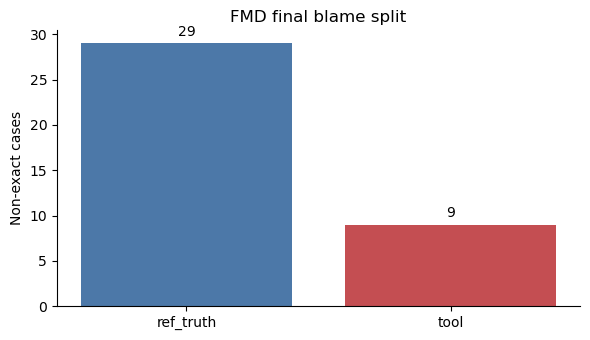

In [10]:
if not fmd_final_summary.empty:
    plot_df = fmd_final_blame_summary.set_index('final_blame')['cases'].reindex(['ref_truth', 'tool'], fill_value=0)
    fig, ax = plt.subplots(figsize=(6, 3.5))
    bars = ax.bar(plot_df.index, plot_df.values, color=[BLAME_COLORS.get(x, '#888') for x in plot_df.index])
    ax.set_ylabel('Non-exact cases')
    ax.set_title('FMD final blame split')
    ax.bar_label(bars, padding=3)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'fmd_final_blame_split.png', dpi=180, bbox_inches='tight')


## Case Table

Compact table for manual reading.

In [11]:
final_case_cols = [
    'record_id', 'ref_name', 'truth_name', 'best_overlap_name',
    'ref_len', 'pred_len', 'truth_len', 'pred_minus_ref_len', 'truth_minus_ref_len', 'pred_minus_truth_len',
    'delta_start', 'delta_end', 'failure_mode', 'status', 'coverage', 'identity', 'iou', 'best_iou',
    'final_blame', 'final_cause', 'final_explanation',
]
final_case_cols = [col for col in final_case_cols if col in fmd_final.columns]
fmd_final_cases = fmd_final[final_case_cols].sort_values(['final_blame', 'final_cause', 'ref_name', 'record_id']) if not fmd_final.empty else pd.DataFrame()
fmd_final_cases.to_csv(OUTPUT_DIR / 'fmd_failure_final_cases.tsv', sep='	', index=False)
fmd_final_cases.head(80)

,record_id,ref_name,truth_name,best_overlap_name,ref_len,pred_len,truth_len,pred_minus_ref_len,truth_minus_ref_len,pred_minus_truth_len,...,delta_end,failure_mode,status,coverage,identity,iou,best_iou,final_blame,final_cause,final_explanation
1,AY687333.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,0.0,Wrong coords,ok,1.0000,88.9,0.8889,0.8889,ref_truth,ref_query_boundary_convention_mismatch,Prediction length matches the reference featur...
5,AY687334.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,0.0,Wrong coords,ok,1.0000,88.9,0.8889,0.8889,ref_truth,ref_query_boundary_convention_mismatch,Prediction length matches the reference featur...
10,LC036265.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,0.0,Wrong coords,ok_extrapolated,0.9444,100.0,0.8889,0.8889,ref_truth,ref_query_boundary_convention_mismatch,Prediction length matches the reference featur...
12,MG372727.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,0.0,Wrong coords,ok,1.0000,94.4,0.8889,0.8889,ref_truth,ref_query_boundary_convention_mismatch,Prediction length matches the reference featur...
14,MG372728.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,0.0,Wrong coords,ok,1.0000,100.0,0.8889,0.8889,ref_truth,ref_query_boundary_convention_mismatch,Prediction length matches the reference featur...
16,MG372729.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,0.0,Wrong coords,ok,1.0000,100.0,0.8889,0.8889,ref_truth,ref_query_boundary_convention_mismatch,Prediction length matches the reference featur...
18,MG372730.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,0.0,Wrong coords,ok,1.0000,100.0,0.8889,0.8889,ref_truth,ref_query_boundary_convention_mismatch,Prediction length matches the reference featur...
21,MG372731.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,0.0,Wrong coords,ok,1.0000,94.4,0.8889,0.8889,ref_truth,ref_query_boundary_convention_mismatch,Prediction length matches the reference featur...
23,MG372732.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,0.0,Wrong coords,ok,1.0000,100.0,0.8889,0.8889,ref_truth,ref_query_boundary_convention_mismatch,Prediction length matches the reference featur...
25,MK088170.1,2A,2A,2A,54,54.0,48.0,0.0,-6.0,6.0,...,0.0,Wrong coords,ok,1.0000,100.0,0.8889,0.8889,ref_truth,ref_query_boundary_convention_mismatch,Prediction length matches the reference featur...
